# Activation Lab — run explorer

Load a completed run and explore its captured activations. Set `RUN_DIR` below to a directory produced by `activation-lab run`.

In [1]:
from pathlib import Path
from activation_lab.view import Run

RUN_DIR = sorted(Path('../runs').glob('*'))[-1]  # most recent run
run = Run(RUN_DIR)
run.summary()

/Users/cornel.stefanache/Projects/Personal/Research/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'model': 'Qwen/Qwen1.5-0.5B',
 'num_layers': 24,
 'hidden_size': 1024,
 'device': 'mps',
 'num_steps': 8,
 'generated': 'The capital of France is Paris.<|im_end|>',
 'prompt': '<|im_start|>system\nYou are a helpful assistant<|im_end|>\n<|im_start|>user\nWhat is the capital of France?<|im_end|>\n<|im_start|>assistant\n'}

## Step list

In [2]:
for s in run.steps:
    print(f"  step {s.step:>3} {s.kind:<7} seq_len={s.seq_len:>4}  \u2192 {s.generated_token!r}")

  step   0 prefill seq_len=  25  → 'The'
  step   1 decode  seq_len=  27  → ' capital'
  step   2 decode  seq_len=  28  → ' of'
  step   3 decode  seq_len=  29  → ' France'
  step   4 decode  seq_len=  30  → ' is'
  step   5 decode  seq_len=  31  → ' Paris'
  step   6 decode  seq_len=  32  → '.'
  step   7 decode  seq_len=  33  → '<|im_end|>'


## Heatmap — residual stream for a layer/step

<Axes: title={'center': 'hidden_out layer=12 step=0 shape=(25, 1024)'}, xlabel='channel', ylabel='pos'>

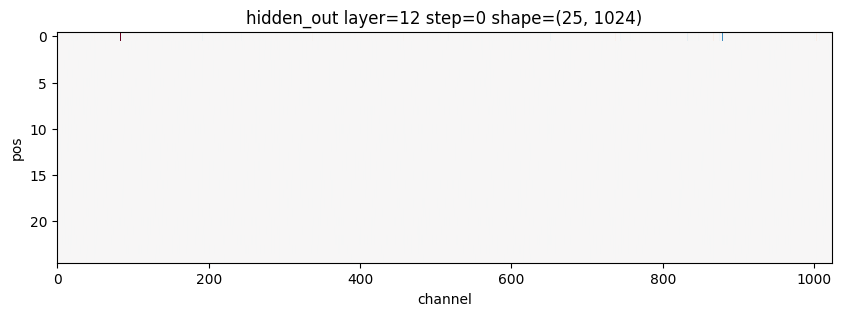

In [3]:
run.heatmap(layer=run.num_layers // 2, step=0, source='hidden_out')

## Residual-stream magnitudes per layer

<Axes: title={'center': 'Residual stream magnitudes — step 0'}, xlabel='layer', ylabel='L2 norm'>

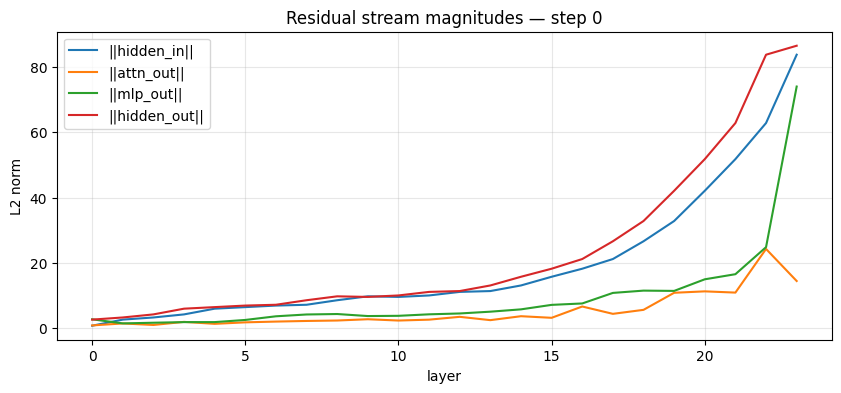

In [4]:
run.plot_residual_norms(step=0)

## Neuron trajectory across steps

Pick a neuron in the MLP intermediate space and watch how its activation evolves through generation.

<Axes: title={'center': 'Neuron L12#0 trajectory (mlp_act)'}, xlabel='step', ylabel='activation'>

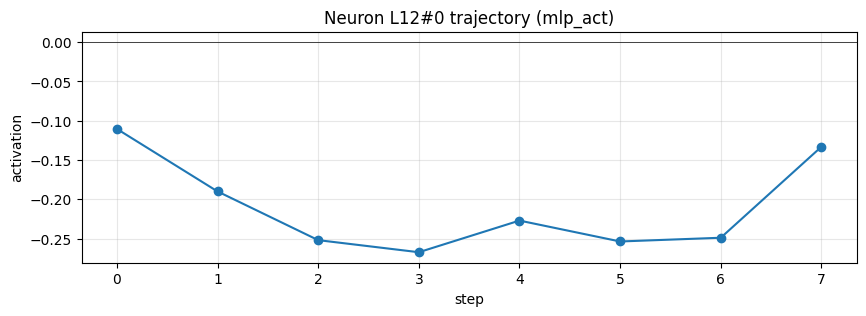

In [5]:
run.plot_neuron(layer=run.num_layers // 2, neuron=0, source='mlp_act')

## Cross-layer cosine similarity

<Axes: title={'center': 'Cross-layer cosine (hidden_out) — step 0'}, xlabel='layer', ylabel='layer'>

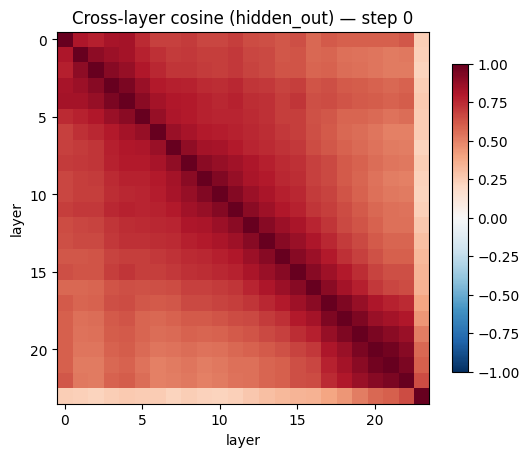

In [6]:
run.plot_cross_layer_cosine(step=0, source='hidden_out')

## Logit lens — reloads the model (slow the first time)

Projects every layer's `hidden_out` through the model's final norm and LM head, returning the top-k tokens each layer would predict. KL-from-final shows how far that layer is from the model's actual output.

In [7]:
import pandas as pd
rows = run.logit_lens_table(step=0, position=-1, top_k=5)
pd.DataFrame(rows)

`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 291/291 [00:00<00:00, 7988.21it/s]


,layer,argmax_token,argmax_logprob,kl_from_final,top
0,0,\n,-3.805,8.886,"[(\n, -3.81), ( \n, -4.84), ( ;\n, -5.42), (:\..."
1,1,""",\n\n",-4.449,10.487,"[("",\n\n, -4.45), (眼, -4.5), (thur, -4.63), ((..."
2,2,"()"",",-4.499,10.365,"[(()"",, -4.5), (:\n\n, -4.66), (/,\n, -5.17), ..."
3,3,"()"",",-4.537,9.663,"[(()"",, -4.54), (-headed, -4.78), (�, -5.24), ..."
4,4,entered,-5.490,9.677,"[( entered, -5.49), (-Man, -5.62), ( breath, -..."
5,5,bib,-3.410,9.981,"[(bib, -3.41), (-Man, -4.56), ( closest, -5.11..."
6,6,alter,-4.020,10.283,"[(alter, -4.02), (-Man, -4.79), (ent, -4.94), ..."
7,7,bes,-4.145,10.167,"[(bes, -4.15), (-Man, -4.36), (lice, -5.03), (..."
8,8,-Man,-4.166,10.276,"[(-Man, -4.17), (-Bar, -4.59), (根據, -5.09), (u..."
9,9,-Bar,-3.581,10.566,"[(-Bar, -3.58), (foil, -3.78), (.Tasks, -4.0),..."
